Install Java

In [1]:
# Install Java 8 (Hadoop requires Java)
!apt-get install -y openjdk-8-jdk-headless -qq > /dev/null
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-8-openjdk-amd64'
!java -version


openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


Download and Install Hadoop

In [2]:
# Download Hadoop 3.3.6
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop-3.3.6.tar.gz
!ls hadoop-3.3.6/


bin  include  libexec	      licenses-binary  NOTICE-binary  README.txt  share
etc  lib      LICENSE-binary  LICENSE.txt      NOTICE.txt     sbin


Set Hadoop Environment Variables

In [3]:
import os
os.environ['HADOOP_HOME'] = '/content/hadoop-3.3.6'
os.environ['JAVA_HOME']   = '/usr/lib/jvm/java-8-openjdk-amd64'
os.environ['PATH']        = os.environ['PATH'] + ':/content/hadoop-3.3.6/bin:/content/hadoop-3.3.6/sbin'

# Verify Hadoop installation
!hadoop version


Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /content/hadoop-3.3.6/share/hadoop/common/hadoop-common-3.3.6.jar


Create Sample Weather Data File

In [4]:
# Create sample_weather.txt (NCDC-style fixed-width weather data)
# Columns: STN WBAN YEARMODA TEMP DEWP WDSP
# We use a simple space-separated format for easy parsing

weather_data = """STN    WBAN   YEARMODA  TEMP   DEWP   WDSP
123456 99999  20200101  72.5   55.3   12.4
123456 99999  20200102  68.2   50.1   10.2
123456 99999  20200103  75.8   58.6   15.3
123456 99999  20200104  80.1   62.4   18.7
123456 99999  20200105  65.3   48.9   8.5
123456 99999  20200106  70.4   53.2   11.6
123456 99999  20200107  78.9   60.5   14.8
123456 99999  20200108  82.3   65.1   20.2
123456 99999  20200109  69.7   52.8   9.9
123456 99999  20200110  74.6   57.4   13.5
123456 99999  20200111  77.2   59.8   16.1
123456 99999  20200112  63.5   47.2   7.8
123456 99999  20200113  71.8   54.6   12.0
123456 99999  20200114  85.4   67.3   22.4
123456 99999  20200115  66.9   51.0   10.7
"""

with open('sample_weather.txt', 'w') as f:
    f.write(weather_data)

print("sample_weather.txt created successfully!")
print("\nFirst 5 lines of the weather file:")
!head -5 sample_weather.txt


sample_weather.txt created successfully!

First 5 lines of the weather file:
STN    WBAN   YEARMODA  TEMP   DEWP   WDSP
123456 99999  20200101  72.5   55.3   12.4
123456 99999  20200102  68.2   50.1   10.2
123456 99999  20200103  75.8   58.6   15.3
123456 99999  20200104  80.1   62.4   18.7


Write the Mapper (Python)

In [5]:
# Write mapper.py
# Mapper reads each weather line, extracts TEMP, DEWP, WDSP
# Emits: ("TEMP", value), ("DEWP", value), ("WDSP", value)

mapper_code = '''#!/usr/bin/env python3
import sys

for line in sys.stdin:
    line = line.strip()
    if not line:
        continue
    parts = line.split()
    # Skip header line
    if parts[0] == "STN":
        continue
    # Format: STN WBAN YEARMODA TEMP DEWP WDSP
    # Index:   0    1     2      3    4    5
    if len(parts) >= 6:
        try:
            temp = float(parts[3])   # Temperature
            dewp = float(parts[4])   # Dew Point
            wdsp = float(parts[5])   # Wind Speed
            # Emit (field_name, value) pairs
            print(f"TEMP\\t{temp}")
            print(f"DEWP\\t{dewp}")
            print(f"WDSP\\t{wdsp}")
        except ValueError:
            pass  # Skip lines with non-numeric values
'''

with open('mapper.py', 'w') as f:
    f.write(mapper_code)

!chmod +x mapper.py
print("mapper.py created successfully")
print("\n--- mapper.py content ---")
!cat mapper.py


mapper.py created successfully

--- mapper.py content ---
#!/usr/bin/env python3
import sys

for line in sys.stdin:
    line = line.strip()
    if not line:
        continue
    parts = line.split()
    # Skip header line
    if parts[0] == "STN":
        continue
    # Format: STN WBAN YEARMODA TEMP DEWP WDSP
    # Index:   0    1     2      3    4    5
    if len(parts) >= 6:
        try:
            temp = float(parts[3])   # Temperature
            dewp = float(parts[4])   # Dew Point
            wdsp = float(parts[5])   # Wind Speed
            # Emit (field_name, value) pairs
            print(f"TEMP\t{temp}")
            print(f"DEWP\t{dewp}")
            print(f"WDSP\t{wdsp}")
        except ValueError:
            pass  # Skip lines with non-numeric values


Write the Reducer (Python)

In [6]:
# Write reducer.py
# Reducer receives sorted (field_name, value) pairs
# Computes the AVERAGE for each field: TEMP, DEWP, WDSP

reducer_code = '''#!/usr/bin/env python3
import sys

current_key   = None
total         = 0.0
count         = 0

for line in sys.stdin:
    line = line.strip()
    if not line:
        continue
    key, value = line.split("\\t", 1)
    value = float(value)

    if current_key == key:
        total += value      # Same field: accumulate sum
        count += 1          # Increment count
    else:
        if current_key is not None:
            average = total / count
            print(f"{current_key}\\tAverage = {average:.2f}")  # Emit average
        current_key = key
        total       = value
        count       = 1

# Emit the last key
if current_key is not None:
    average = total / count
    print(f"{current_key}\\tAverage = {average:.2f}")
'''

with open('reducer.py', 'w') as f:
    f.write(reducer_code)

!chmod +x reducer.py
print("reducer.py created successfully")
print("\n--- reducer.py content ---")
!cat reducer.py


reducer.py created successfully

--- reducer.py content ---
#!/usr/bin/env python3
import sys

current_key   = None
total         = 0.0
count         = 0

for line in sys.stdin:
    line = line.strip()
    if not line:
        continue
    key, value = line.split("\t", 1)
    value = float(value)

    if current_key == key:
        total += value      # Same field: accumulate sum
        count += 1          # Increment count
    else:
        if current_key is not None:
            average = total / count
            print(f"{current_key}\tAverage = {average:.2f}")  # Emit average
        current_key = key
        total       = value
        count       = 1

# Emit the last key
if current_key is not None:
    average = total / count
    print(f"{current_key}\tAverage = {average:.2f}")


Test Mapper Output Locally

In [7]:
# Test: See what the Mapper emits (intermediate key-value pairs)
print("=== MAPPER OUTPUT (intermediate key-value pairs) ===")
!cat sample_weather.txt | python3 mapper.py


=== MAPPER OUTPUT (intermediate key-value pairs) ===
TEMP	72.5
DEWP	55.3
WDSP	12.4
TEMP	68.2
DEWP	50.1
WDSP	10.2
TEMP	75.8
DEWP	58.6
WDSP	15.3
TEMP	80.1
DEWP	62.4
WDSP	18.7
TEMP	65.3
DEWP	48.9
WDSP	8.5
TEMP	70.4
DEWP	53.2
WDSP	11.6
TEMP	78.9
DEWP	60.5
WDSP	14.8
TEMP	82.3
DEWP	65.1
WDSP	20.2
TEMP	69.7
DEWP	52.8
WDSP	9.9
TEMP	74.6
DEWP	57.4
WDSP	13.5
TEMP	77.2
DEWP	59.8
WDSP	16.1
TEMP	63.5
DEWP	47.2
WDSP	7.8
TEMP	71.8
DEWP	54.6
WDSP	12.0
TEMP	85.4
DEWP	67.3
WDSP	22.4
TEMP	66.9
DEWP	51.0
WDSP	10.7


Test Full MapReduce Pipeline Locally (without Hadoop)

In [8]:
# Test: Full MapReduce pipeline locally (Map -> Sort -> Reduce)
print("=== FULL MapReduce PIPELINE (local simulation) ===")
print("Input -> Mapper -> Sort (shuffle) -> Reducer -> Output")
print()
!cat sample_weather.txt | python3 mapper.py | sort | python3 reducer.py


=== FULL MapReduce PIPELINE (local simulation) ===
Input -> Mapper -> Sort (shuffle) -> Reducer -> Output

DEWP	Average = 56.28
TEMP	Average = 73.51
WDSP	Average = 13.61


Configure Hadoop for Standalone Mode

In [9]:
# Set JAVA_HOME inside Hadoop config (required for Hadoop to find Java)
hadoop_env_path = '/content/hadoop-3.3.6/etc/hadoop/hadoop-env.sh'
with open(hadoop_env_path, 'a') as f:
    f.write('\nexport JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64\n')

print("Hadoop configured for standalone mode")
!hadoop version


Hadoop configured for standalone mode
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /content/hadoop-3.3.6/share/hadoop/common/hadoop-common-3.3.6.jar


Upload Weather File to HDFS

In [10]:
# Create HDFS input directory and upload weather file
!hadoop fs -mkdir -p /weatherinput
!hadoop fs -put sample_weather.txt /weatherinput/
!hadoop fs -ls /weatherinput
print("\nWeather file uploaded to HDFS successfully")


Found 1 items
-rw-r--r--   1 root root        685 2026-05-04 08:33 /weatherinput/sample_weather.txt

Weather file uploaded to HDFS successfully


Run the MapReduce Job on Hadoop

In [11]:
# Remove output directory if it exists (for re-runs)
!hadoop fs -rm -r /weatheroutput 2>/dev/null || true

# Run the MapReduce job using Hadoop Streaming
print("=== RUNNING MapReduce JOB ON HADOOP ===")
!hadoop jar /content/hadoop-3.3.6/share/hadoop/tools/lib/hadoop-streaming-*.jar \
    -input /weatherinput/sample_weather.txt \
    -output /weatheroutput \
    -mapper mapper.py \
    -reducer reducer.py \
    -file mapper.py \
    -file reducer.py


=== RUNNING MapReduce JOB ON HADOOP ===
2026-05-04 08:33:33,430 WARN streaming.StreamJob: -file option is deprecated, please use generic option -files instead.
packageJobJar: [mapper.py, reducer.py] [] /tmp/streamjob5101203017216094972.jar tmpDir=null
2026-05-04 08:33:34,145 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2026-05-04 08:33:34,237 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2026-05-04 08:33:34,237 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2026-05-04 08:33:34,260 WARN impl.MetricsSystemImpl: JobTracker metrics system already initialized!
2026-05-04 08:33:34,493 INFO mapred.FileInputFormat: Total input files to process : 1
2026-05-04 08:33:34,514 INFO mapreduce.JobSubmitter: number of splits:1
2026-05-04 08:33:34,687 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1324242969_0001
2026-05-04 08:33:34,687 INFO mapreduce.JobSubmitter: Executing with tokens: []
2026-05-04 08:33:

View the Output

In [12]:
# View the MapReduce output from HDFS
print("=== MapReduce OUTPUT (Average Weather Values) ===")
!hadoop fs -cat /weatheroutput/part-00000


=== MapReduce OUTPUT (Average Weather Values) ===
DEWP	Average = 56.28
TEMP	Average = 73.51
WDSP	Average = 13.61


List Output Files in HDFS

In [13]:
# List output files in HDFS
print("=== Output files in HDFS ===")
!hadoop fs -ls /weatheroutput


=== Output files in HDFS ===
Found 2 items
-rw-r--r--   1 root root          0 2026-05-04 08:33 /weatheroutput/_SUCCESS
-rw-r--r--   1 root root         63 2026-05-04 08:33 /weatheroutput/part-00000


Visualize the Results

Average Weather Values:
  Dew Point (°F)            : 56.28
  Temperature (°F)          : 73.51
  Wind Speed (knots)        : 13.61


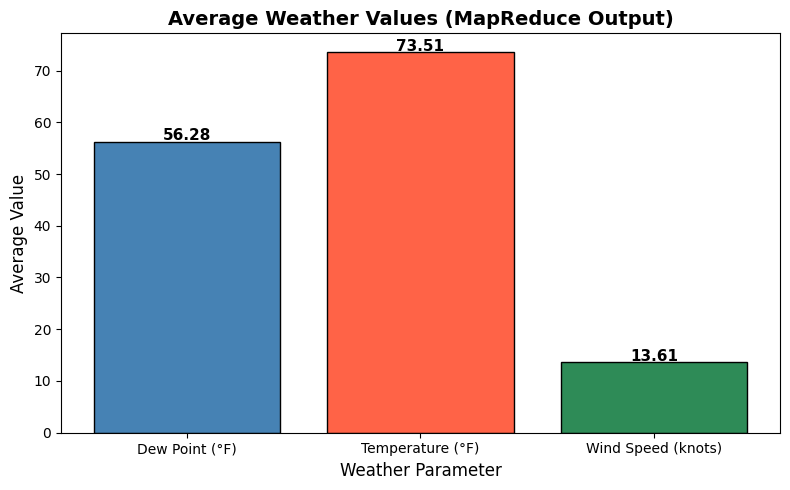

Chart saved as weather_averages.png


In [14]:
import matplotlib.pyplot as plt
import subprocess

# Read output from HDFS
result = subprocess.run(
    ['hadoop', 'fs', '-cat', '/weatheroutput/part-00000'],
    capture_output=True, text=True
)

# Parse the output
# Format: FIELD\tAverage = VALUE
weather_avgs = {}
for line in result.stdout.strip().split('\n'):
    if line.strip():
        parts = line.split('\t')
        if len(parts) == 2:
            field = parts[0]                          # e.g., TEMP
            avg_val = float(parts[1].split('=')[1])   # e.g., 73.47
            weather_avgs[field] = avg_val

print("Average Weather Values:")
labels = {'TEMP': 'Temperature (°F)', 'DEWP': 'Dew Point (°F)', 'WDSP': 'Wind Speed (knots)'}
for field, avg in sorted(weather_avgs.items()):
    print(f"  {labels.get(field, field):25s} : {avg:.2f}")

# Bar chart
colors = {'TEMP': 'tomato', 'DEWP': 'steelblue', 'WDSP': 'seagreen'}
bar_colors = [colors.get(k, 'gray') for k in weather_avgs.keys()]
bar_labels  = [labels.get(k, k) for k in weather_avgs.keys()]

plt.figure(figsize=(8, 5))
bars = plt.bar(bar_labels, weather_avgs.values(), color=bar_colors, edgecolor='black')
plt.title('Average Weather Values (MapReduce Output)', fontsize=14, fontweight='bold')
plt.xlabel('Weather Parameter', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
for bar, val in zip(bars, weather_avgs.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('weather_averages.png', dpi=150)
plt.show()
print("Chart saved as weather_averages.png")


In [ ]:

---

## CODE EXPLANATION

### Mapper (mapper.py)
- Reads each line from stdin
- Skips the header line (where parts[0] == "STN")
- Extracts TEMP (index 3), DEWP (index 4), WDSP (index 5)
- Emits three key-value pairs per line:
  - `TEMP\t72.5`
  - `DEWP\t55.3`
  - `WDSP\t12.4`

### Reducer (reducer.py)
- Receives sorted (field, value) pairs from Mapper
- Accumulates sum and count for each field
- Computes average = total / count
- Emits `FIELD\tAverage = value`

---

## KEY DIFFERENCE FROM WEATHER DATA (Java) PRACTICAL

| Feature | Java (MyMaxMin) | Python (This Practical) |
|---------|----------------|------------------------|
| API | New MapReduce API | Hadoop Streaming |
| Language | Java | Python |
| Goal | Classify Hot/Cold days | Compute averages |
| Output key | Day label + date | Field name (TEMP/DEWP/WDSP) |
| Parsing | substring() by position | split() by whitespace |

---

## POSSIBLE ORAL EXAM QUESTIONS

**Q: What is this practical about?**
A: It reads a weather data file and uses Hadoop MapReduce to compute the average Temperature, Dew Point, and Wind Speed across all records.

**Q: What does the Mapper do?**
A: It reads each line, skips the header, extracts TEMP, DEWP, and WDSP values, and emits three (field_name, value) pairs per line.

**Q: What does the Reducer do?**
A: It receives all values grouped by field name (after shuffle & sort), sums them up, divides by count, and emits the average for each field.

**Q: What is Dew Point?**
A: Dew Point (DEWP) is the temperature at which air becomes saturated with moisture and dew begins to form. It is a measure of humidity.

**Q: What is Wind Speed (WDSP)?**
A: WDSP is the average wind speed in knots recorded at the weather station.

**Q: Why do we skip the header line in the Mapper?**
A: The header line contains column names (STN, WBAN, TEMP, etc.) not numeric data. Trying to parse it as float would cause a ValueError, so we skip it.

**Q: What is Hadoop Streaming?**
A: Hadoop Streaming is a utility that allows writing Mapper and Reducer in any language (Python, Ruby, etc.) using stdin/stdout for communication with Hadoop.

**Q: What is the Shuffle and Sort phase?**
A: After Map, Hadoop automatically groups all values with the same key and sorts them. So all TEMP values go to one Reducer call, all DEWP to another, etc.
